# Temporal Decay (Rolling-Horizon Generalization) -- EDA

Visualizes the output of `run_temporal_decay_experiment`
(`thesis.experiments.temporal_decay`). The configs come straight from the
mining parameter grid: every named entry in
`configs/screening_mining_settings.yaml` (the `max_depth` x
`max_depth_attack` grid the mining EDA settled on, growth_rate / coverage /
class_weight frozen) crossed with the `--granularities` and `--models` the
run was launched with, plus a no-symbolic baseline per granularity. There
is no separate screening / shortlist step.

Models are supervised classifiers (`logreg`, `xgboost`, ...) or one-class
anomaly detectors (`iforest`, `ocsvm` -- fit on benign rows, Platt-scaled
to an attack probability). Both are frozen and walked the same way.

For each config a schema+model is mined/fit once on window 0's train split
(W_src is always the first window) and frozen, then walked forward one
window at a time to the end of the timeline. `h=0` is W_src's own held-out
test split; every horizon after that is a fully external window.

This notebook draws:
- **§1** one degradation figure -- every logged metric (`auc`, `f1`,
  `accuracy`, `precision`, `recall`, `fpr`) vs. horizon, `PRIMARY_METRIC`
  first, one curve per grid setting, at a single granularity;
- **§2** the decay-summary table (h=0 vs. the last horizon reached);
- **§3** a per-horizon feature-importance heatmap for one selected config
  (which schema features drive the model's output, and how that shifts as
  the horizon grows).

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from thesis.experiments._shared import METRIC_COLS
from thesis.paths import RESULTS_DIR

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Thresholds

Edit and re-run below -- nothing past this cell needs to change.

In [2]:
SCENARIO = "cscas"
RUN_ID = None  # None -> latest run dir for SCENARIO

PRIMARY_METRIC = "auc"  # drawn first in §1 (which now plots every logged
                        # metric); also drives §1's near-duplicate check and
                        # §2's decay-summary sort
GRANULARITY = None  # None -> finest granularity in the run (most horizons);
                    # or pin one the run used, e.g. 0.1
INCLUDE_BASELINE = True  # §1: draw the no-symbolic baseline curve too. It
                         # sits far above the symbolic curves on FPR, which
                         # can flatten them -- set False to rescale §1 to the
                         # grid settings only.

LINE_COLOR = "#4477AA"

# §3 heatmap: which (feature_set, mining_setting, granularity, model) config
# to show -- see the printed list in that section, then set this to its row
# index.
CONFIG_SELECT = 0
HEATMAP_TOP_K = 20  # schema features shown (rows), ranked by pooled mean |importance|

In [3]:
sweep_dir = RESULTS_DIR / "sys-eval" / "temporal-decay" / SCENARIO
# Curated, human-facing mirror of the run (see thesis.paths.RESULTS_DIR /
# system_eval.temporal_decay's module docstring) -- unlike its
# artifacts/experiments/temporal_decay/<scenario>/ source, this mirror
# holds only run directories (no _derived_shortlist.csv), but the is_dir()
# filter is kept anyway as a cheap guard against picking a stray file.
run_dirs = [p for p in sweep_dir.iterdir() if p.is_dir()]
run_dir = sweep_dir / RUN_ID if RUN_ID else sorted(run_dirs)[-1]


def _read_csv_maybe_empty(path) -> pd.DataFrame:
    """A run launched with compute_explanations=False (see config.json)
    writes explanations.csv / lime_fidelity.csv from an empty DataFrame --
    just a blank line, no header -- which pd.read_csv rejects with
    EmptyDataError. Treat that as zero rows rather than a load failure."""
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


per_horizon = pd.read_csv(run_dir / "per_horizon_results.csv")
decay_summary = pd.read_csv(run_dir / "decay_summary.csv")
explanations = _read_csv_maybe_empty(run_dir / "explanations.csv")
lime_fidelity = _read_csv_maybe_empty(run_dir / "lime_fidelity.csv")

print(f"Loaded from {run_dir}")
print(f"per_horizon_results: {len(per_horizon)} rows")
print(f"decay_summary:       {len(decay_summary)} rows")
print(f"explanations:         {len(explanations)} rows")
print(f"lime_fidelity:        {len(lime_fidelity)} rows")
if explanations.empty:
    print("note: no explanations logged for this run (compute_explanations=False, "
          "or SHAP/LIME failed at every horizon) -- §3 heatmap will have nothing to show")
print(f"grid settings: {sorted(per_horizon['mining_setting'].dropna().unique())}")
print(f"granularities:  {sorted(per_horizon['granularity'].dropna().unique())}")
per_horizon.head()

Loaded from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/results/sys-eval/temporal-decay/cscas/20260909_040121
per_horizon_results: 488 rows
decay_summary:       80 rows
explanations:         0 rows
lime_fidelity:        0 rows
note: no explanations logged for this run (compute_explanations=False, or SHAP/LIME failed at every horizon) -- §3 heatmap will have nothing to show
grid settings: ['gr3_md1_mda2', 'gr3_md1_mda3', 'gr3_md1_mda4', 'gr3_md2_mda2', 'gr3_md2_mda3', 'gr3_md2_mda4']
granularities:  [0.1, 0.25, 0.5]


,scenario,feature_set,mining_setting,granularity,model,n_windows,threshold_mode,threshold,mining_cache_hit,horizon_window_index,horizon_fraction,is_source_window,target_single_class,n_alert_groups,n_attack,auc,accuracy,precision,recall,f1,tp,fp,tn,fn,fpr
0,cscas,symbolic,gr3_md1_mda2,0.25,logreg,5,fixed,0.5,False,0,0.00,True,False,41860,388,0.998149,0.994577,0.634391,0.979381,0.770010,380,219,41253,8,0.005281
1,cscas,symbolic,gr3_md1_mda2,0.25,logreg,5,fixed,0.5,False,1,0.25,False,False,313948,3860,0.992926,0.993168,0.647565,0.974870,0.778203,3763,2048,308040,97,0.006605
2,cscas,symbolic,gr3_md1_mda2,0.25,logreg,5,fixed,0.5,False,2,0.50,False,False,313948,6268,0.995336,0.991980,0.721317,0.974952,0.829172,6111,2361,305319,157,0.007674
3,cscas,symbolic,gr3_md1_mda2,0.25,logreg,5,fixed,0.5,False,3,0.75,False,False,313948,4437,0.991374,0.992648,0.668460,0.951995,0.785422,4224,2095,307416,213,0.006769
4,cscas,symbolic,gr3_md1_mda2,0.25,logreg,5,fixed,0.5,False,4,1.00,False,False,313948,4622,0.995177,0.992339,0.667169,0.957161,0.786279,4424,2207,307119,198,0.007135


## 1. Degradation curve

**One figure**, one panel per logged metric (`auc`, `f1`, `accuracy`,
`precision`, `recall`, `fpr` -- `PRIMARY_METRIC` drawn first), **one curve
per grid setting**, all at a single granularity (`GRANULARITY` above --
default the finest, which has the most horizons). Each curve walks forward
from window 0 to the end of the timeline. The `h=0` point (W_src's own
held-out test split, never seen by mining or fitting) is starred; every
later point is a fully external window.

The no-symbolic baseline is the dashed black line (`INCLUDE_BASELINE`). On
FPR it sits far above the symbolic curves, so those can look flat against
it -- set `INCLUDE_BASELINE = False` to rescale to the grid settings only.
Pass e.g. `plot_degradation(metrics=("auc", "fpr"))` to draw a subset
instead of every metric.

Horizon is a window index and window count scales with granularity, so one
figure fixes one granularity to keep the x-axis comparable across settings
-- change `GRANULARITY` to see another.

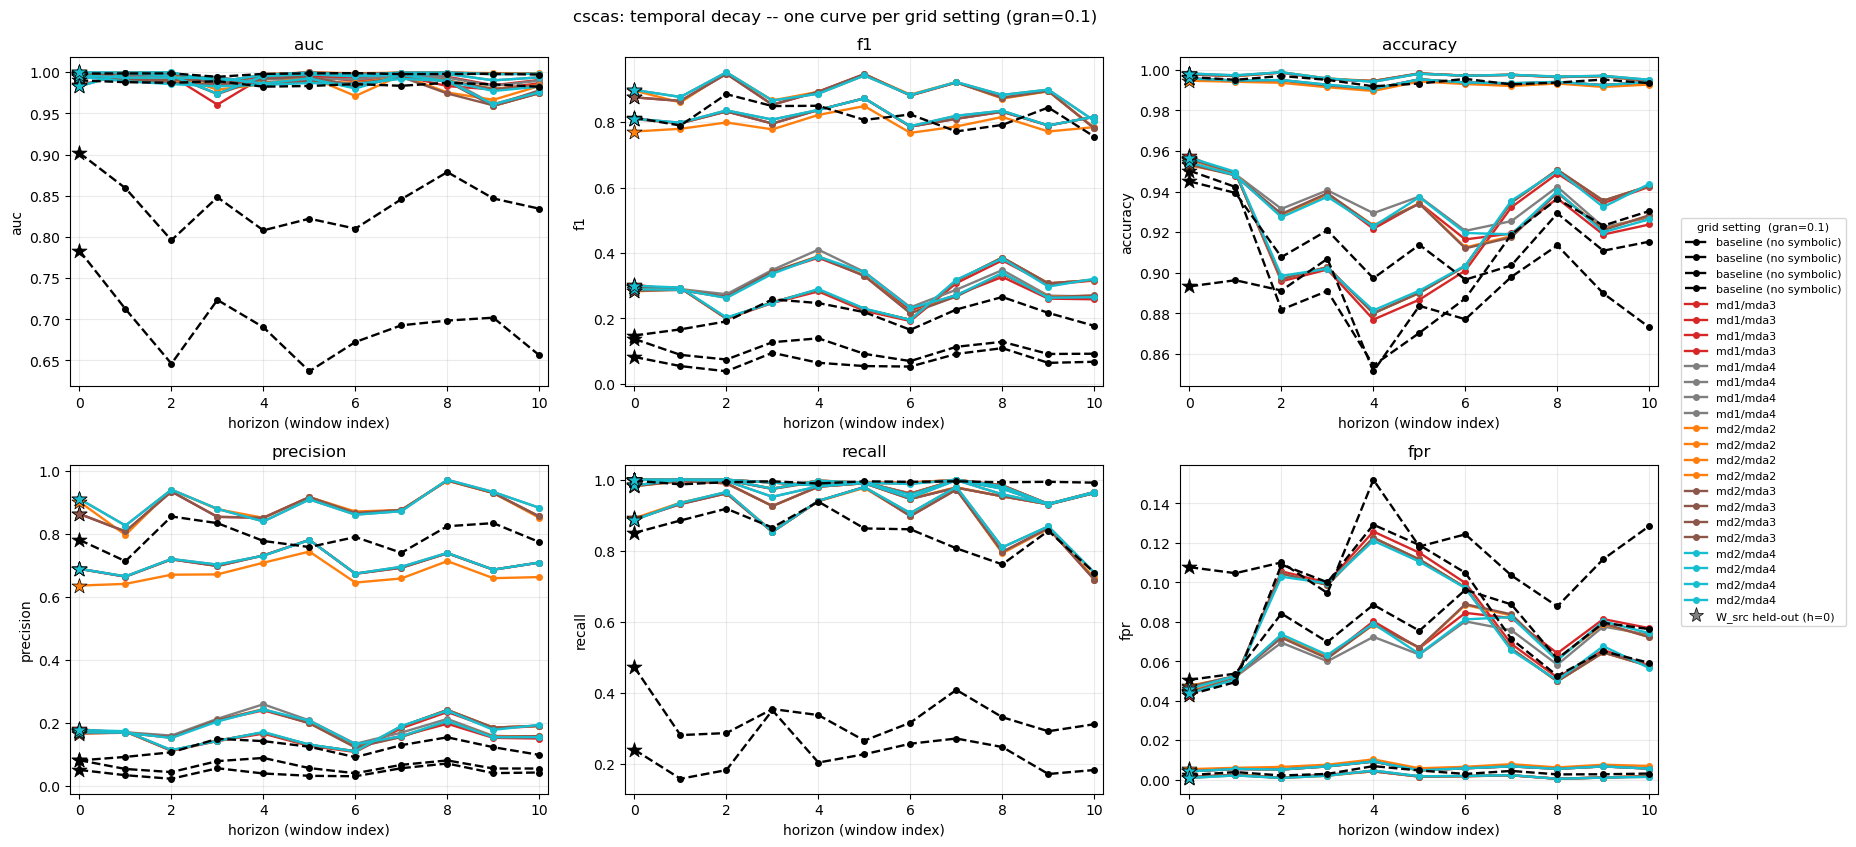

In [4]:
from matplotlib.lines import Line2D

CONFIG_COLS = ["feature_set", "mining_setting", "granularity", "model"]
GROUP_COLS = [c for c in CONFIG_COLS if c != "granularity"]


def config_label(row) -> str:
    return f"{row['feature_set']}/{row['mining_setting']} g={row['granularity']:g}"


def group_label(row) -> str:
    """Short legend label for one grid setting (granularity-independent).
    The mining-grid entries share a frozen growth_rate prefix (gr3_ -- see
    the mining EDA), so drop it: gr3_md1_mda2 -> md1/mda2. Baseline carries
    no mining_setting."""
    ms = row["mining_setting"]
    if pd.isna(ms):
        return "baseline (no symbolic)"
    ms = str(ms)
    if ms.startswith("gr3_"):
        ms = ms[4:]
    return ms.replace("_", "/")


def _resolve_gran() -> float:
    grans = sorted(per_horizon["granularity"].dropna().unique())
    if GRANULARITY is None:
        return grans[0]  # finest -> most horizons -> longest decay curve
    if GRANULARITY not in grans:
        raise ValueError(f"GRANULARITY={GRANULARITY} not in this run ({grans})")
    return GRANULARITY


def _grid_settings(df: pd.DataFrame) -> list[dict]:
    """One dict per grid setting present in `df`, baseline first then mining
    settings by name. groupby(dropna=False) so the baseline row (NaN
    mining_setting) isn't dropped the way an `== NaN` mask would drop it."""
    keys = list(df.groupby(GROUP_COLS, dropna=False, sort=False).groups)
    keys.sort(key=lambda k: (k[0] != "baseline", "" if pd.isna(k[1]) else str(k[1])))
    return [dict(zip(GROUP_COLS, k)) for k in keys]


def _setting_mask(df: pd.DataFrame, s: dict) -> pd.Series:
    m = df["feature_set"].eq(s["feature_set"]) & df["model"].eq(s["model"])
    ms = s["mining_setting"]
    return m & (df["mining_setting"].isna() if pd.isna(ms) else df["mining_setting"].eq(ms))


def _ordered_metrics(metrics=None) -> list[str]:
    """Default to every metric the run logged (METRIC_COLS), PRIMARY_METRIC
    moved to the front so it's always the first panel."""
    if metrics is not None:
        return list(metrics)
    return [PRIMARY_METRIC] + [m for m in METRIC_COLS if m != PRIMARY_METRIC]


def plot_degradation(metrics=None, include_baseline=None) -> None:
    """One figure, one panel per metric (all of METRIC_COLS by default,
    PRIMARY_METRIC first) vs. horizon at a single granularity, one line
    per grid setting. h=0 (W_src's own held-out test split) is starred; the
    baseline (no symbolic features), if drawn, is a dashed black line.

    A shared x-axis (window index) is why this fixes one granularity: finer
    granularity -> more windows -> a longer curve, not comparable on the
    same axis."""
    include_baseline = INCLUDE_BASELINE if include_baseline is None else include_baseline
    metrics = _ordered_metrics(metrics)
    gran = _resolve_gran()
    df = per_horizon[per_horizon["granularity"] == gran]
    settings = _grid_settings(df)
    if not include_baseline:
        settings = [s for s in settings if not pd.isna(s["mining_setting"])]

    palette = plt.get_cmap("tab10")
    mining_names = [s["mining_setting"] for s in settings if not pd.isna(s["mining_setting"])]
    color_of = {name: palette(i % 10) for i, name in enumerate(mining_names)}

    ncols = min(3, len(metrics))
    nrows = -(-len(metrics) // ncols)  # ceil division
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 4.3 * nrows), squeeze=False)
    flat_axes = axes.flatten()
    for ax, metric in zip(flat_axes, metrics):
        for s in settings:
            sub = df[_setting_mask(df, s)].sort_values("horizon_window_index")
            if sub.empty or metric not in sub.columns:
                continue
            baseline = pd.isna(s["mining_setting"])
            color = "black" if baseline else color_of[s["mining_setting"]]
            ax.plot(
                sub["horizon_window_index"], sub[metric],
                linestyle="--" if baseline else "-", color=color,
                marker="o", markersize=4, linewidth=1.7,
                label=group_label(s), zorder=3 if baseline else 2,
            )
            src = sub[sub["is_source_window"]]
            ax.scatter(
                src["horizon_window_index"], src[metric], color=color,
                marker="*", s=130, edgecolor="black", linewidth=0.5, zorder=5,
            )
        ax.set_xlabel("horizon (window index)")
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.grid(alpha=0.25)
        ax.margins(x=0.02)

    for ax in flat_axes[len(metrics):]:
        ax.set_visible(False)

    star = Line2D(
        [], [], color="grey", marker="*", markersize=11, linestyle="None",
        markeredgecolor="black", markeredgewidth=0.5,
    )
    handles, labels = flat_axes[0].get_legend_handles_labels()
    fig.legend(
        handles + [star], labels + ["W_src held-out (h=0)"],
        loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8,
        title=f"grid setting  (gran={gran:g})", title_fontsize=8,
    )
    fig.suptitle(
        f"{SCENARIO}: temporal decay -- one curve per grid setting (gran={gran:g})"
    )
    fig.tight_layout()


plot_degradation()

## 2. Decay summary

Score/FPR at `h=0` (W_src's own held-out test split) vs. the last horizon
actually reached (`h_max`, the final window of the timeline), and their
difference (`decay_rate_{metric} = score(h=0) - score(h_max)`;
`fpr_drift = fpr(h_max) - fpr(h=0)`).

In [6]:
sort_col = f"decay_rate_{PRIMARY_METRIC}"
decay_summary.sort_values(sort_col, ascending=False) if sort_col in decay_summary.columns else decay_summary

,feature_set,mining_setting,granularity,model,h_max,auc_at_h0,auc_at_h10,decay_rate_auc,f1_at_h0,f1_at_h10,decay_rate_f1,accuracy_at_h0,accuracy_at_h10,decay_rate_accuracy,precision_at_h0,precision_at_h10,decay_rate_precision,recall_at_h0,recall_at_h10,decay_rate_recall,fpr_at_h0,fpr_at_h10,fpr_drift,auc_at_h4,f1_at_h4,accuracy_at_h4,precision_at_h4,recall_at_h4,fpr_at_h4,auc_at_h2,f1_at_h2,accuracy_at_h2,precision_at_h2,recall_at_h2,fpr_at_h2
2,baseline,NaN,0.10,ocsvm,10,0.783343,0.656355,0.126988,0.082047,0.067428,0.014619,0.950287,0.930396,0.019891,0.049494,0.041345,0.008149,0.239691,0.182659,0.057032,0.043065,0.059160,0.016095,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,baseline,NaN,0.25,ocsvm,4,0.783343,NaN,0.107632,0.082047,NaN,0.014197,0.950287,NaN,0.021878,0.049494,NaN,0.007524,0.239691,NaN,0.062711,0.043065,NaN,0.017298,0.675711,0.067850,0.928409,0.041970,0.17698,0.060363,NaN,NaN,NaN,NaN,NaN,NaN
10,baseline,NaN,0.50,ocsvm,2,0.783343,NaN,0.099783,0.082047,NaN,0.007518,0.950287,NaN,0.031055,0.049494,NaN,0.004850,0.239691,NaN,0.014280,0.043065,NaN,0.027546,NaN,NaN,NaN,NaN,NaN,NaN,0.683560,0.074528,0.919232,0.044645,0.225411,0.070611
0,baseline,NaN,0.10,iforest,10,0.901898,0.834270,0.067628,0.137181,0.092027,0.045155,0.945007,0.915306,0.029702,0.080263,0.053986,0.026277,0.471649,0.311561,0.160089,0.050564,0.076261,0.025697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,baseline,NaN,0.50,iforest,2,0.901898,NaN,0.058612,0.137181,NaN,0.039717,0.945007,NaN,0.033879,0.080263,NaN,0.023165,0.471649,NaN,0.139052,0.050564,NaN,0.029838,NaN,NaN,NaN,NaN,NaN,NaN,0.843286,0.097464,0.911129,0.057098,0.332597,0.080402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,symbolic,gr3_md2_mda4,0.25,logreg,4,0.982885,NaN,-0.010239,0.810180,NaN,0.000635,0.995724,NaN,0.002359,0.688288,NaN,-0.012741,0.984536,NaN,0.026726,0.004171,NaN,0.001932,0.993124,0.809546,0.993365,0.701029,0.95781,0.006104,NaN,NaN,NaN,NaN,NaN,NaN
33,symbolic,gr3_md1_mda4,0.10,logreg,10,0.982911,0.993688,-0.010777,0.810180,0.816357,-0.006176,0.995724,0.994028,0.001696,0.688288,0.708156,-0.019868,0.984536,0.963584,0.020952,0.004171,0.005547,0.001375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,symbolic,gr3_md2_mda4,0.10,logreg,10,0.982885,0.993679,-0.010793,0.810180,0.816357,-0.006176,0.995724,0.994028,0.001696,0.688288,0.708156,-0.019868,0.984536,0.963584,0.020952,0.004171,0.005547,0.001375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,symbolic,gr3_md2_mda4,0.50,logreg,2,0.982885,NaN,-0.011673,0.810180,NaN,-0.000079,0.995724,NaN,0.002215,0.688288,NaN,-0.012267,0.984536,NaN,0.023834,0.004171,NaN,0.001840,NaN,NaN,NaN,NaN,NaN,NaN,0.994558,0.810260,0.993508,0.700555,0.960702,0.006011


## 3. Per-horizon feature-importance heatmap

For one selected config (`CONFIG_SELECT`), a heatmap of **signed** mean
importance:

- **rows** = the top-`HEATMAP_TOP_K` schema features, ranked by pooled mean
  |importance| across all horizons;
- **columns** = horizon (window index);
- **cell** = mean signed importance over that horizon's explained sample --
  **red pushes the model's prediction toward `attack`, blue toward
  `benign`**, intensity = strength.

One panel per method (SHAP, LIME) that the run logged. Read a row
left-to-right: a feature whose colour fades or flips as the horizon grows
is one whose influence on the model's output is drifting. A grey cell means
that feature wasn't among the logged importances at that horizon (only
possible on older runs -- the experiment now logs every feature).

This shows the model's **output** attribution -- which features move the
score and which way -- not its **accuracy**. A strong row means the model
leans on that feature, not that the feature makes it correct.

In [7]:
# Configs that have logged importances. Symbolic (schema) configs first --
# the heatmap is about the mined schema; baseline is base-features-only.
# Pick one with CONFIG_SELECT above.
if explanations.empty:
    available_configs = pd.DataFrame(columns=CONFIG_COLS)
else:
    available_configs = (
        explanations[CONFIG_COLS].drop_duplicates()
        .assign(_kind=lambda d: d["feature_set"].eq("baseline").astype(int))
        .sort_values(["_kind", "mining_setting", "granularity", "model"], na_position="last")
        .drop(columns="_kind")
        .reset_index(drop=True)
    )


def _config_mask(df: pd.DataFrame, row) -> pd.Series:
    """Row-equality mask that treats NaN == NaN as a match (plain `==`
    never matches NaN, so baseline configs would select nothing)."""
    m = pd.Series(True, index=df.index)
    for c in CONFIG_COLS:
        v = row[c]
        m &= df[c].isna() if pd.isna(v) else df[c].eq(v)
    return m


available_configs

,feature_set,mining_setting,granularity,model


In [8]:
if available_configs.empty:
    print("No logged importances for this run -- nothing to select for the heatmap "
          "(see the note printed when the run was loaded above).")
    selected = None
    selected_explanations = explanations
else:
    selected = available_configs.iloc[CONFIG_SELECT]
    selected_explanations = explanations[_config_mask(explanations, selected)]
    print(f"selected: {config_label(selected)}  ({len(selected_explanations)} importance rows)")


def plot_importance_heatmap(sub: pd.DataFrame, title: str, k: int = HEATMAP_TOP_K) -> None:
    """Signed mean importance per (feature, horizon), top-k features by
    pooled mean |importance| across horizons (a feature absent at a horizon
    counts as 0 for ranking, so the rows shown are the consistently
    influential ones). One panel per method -- SHAP and LIME are different
    units, each ranked and colour-scaled on its own. Red pushes the
    prediction toward attack, blue toward benign; grey = feature not among
    the logged importances at that horizon (pre-"log every feature" runs)."""
    if sub.empty:
        print("No logged importances for this config -- pick another CONFIG_SELECT.")
        return
    methods = sorted(sub["method"].unique())
    horizons = sorted(sub["horizon_window_index"].unique())
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("#e8e8e8")

    fig, axes = plt.subplots(
        1, len(methods),
        figsize=(max(4.5, 0.55 * len(horizons) + 3.0) * len(methods), 0.30 * k + 1.8),
        squeeze=False, sharey=False,
    )
    for ax, method in zip(axes[0], methods):
        pivot = sub[sub["method"] == method].pivot_table(
            index="feature", columns="horizon_window_index",
            values="importance", aggfunc="mean",
        )
        order = pivot.abs().fillna(0).mean(axis=1).sort_values(ascending=False).head(k).index
        pivot = pivot.loc[order]
        vmax = float(np.nanmax(np.abs(pivot.values))) or 1e-9

        im = ax.imshow(
            np.ma.masked_invalid(pivot.values), aspect="auto", cmap=cmap,
            norm=mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax),
        )
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"h{c}" for c in pivot.columns], fontsize=7)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=7)
        ax.set_xlabel("horizon (window index)")
        ax.set_title(f"{method.upper()}  (red → attack, blue → benign)", fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="mean signed importance")

    fig.suptitle(title)
    fig.tight_layout()


if selected is not None:
    plot_importance_heatmap(selected_explanations, config_label(selected))

No logged importances for this run -- nothing to select for the heatmap (see the note printed when the run was loaded above).
